라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import platform
import os
import chardet
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import seaborn as sns
import folium
import shap
import pyproj
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from branca.element import Template, MacroElement

c:\Users\shs86\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


데이터 불러오기

In [2]:
# 1. 파일 경로 정의
file_paths = {
    'sales': "./Original_data/서울시 상권분석서비스(추정매출-상권)_2024년.csv",
    'area': "./Original_data/서울시 상권분석서비스(영역-상권).csv",
    'store': "./Original_data/서울시 상권분석서비스(점포-상권)_2024년.csv",
    'change': "./Original_data/서울시 상권분석서비스(상권변화지표-상권).csv",
    'resident': "./Original_data/서울시 상권분석서비스(상주인구-상권).csv",
    'worker': "./Original_data/서울시 상권분석서비스(직장인구-상권).csv",
    'street': "./Original_data/서울시 상권분석서비스(길단위인구-상권).csv",
    'income': "./Original_data/서울시 상권분석서비스(소득소비-상권).csv",
    'attract': "./Original_data/서울시 상권분석서비스(집객시설-상권).csv"
}

# 2. 인코딩 자동 감지 함수
def detect_encoding(path):
    with open(path, 'rb') as f:
        return chardet.detect(f.read(10000))['encoding']

# 3. 저장 폴더 생성
output_dir = "./filtered"
os.makedirs(output_dir, exist_ok=True)

# 4. 파일 불러오기 및 저장
dfs = {}
for key, path in file_paths.items():
    try:
        enc = detect_encoding(path)
        df = pd.read_csv(path, encoding=enc)
        dfs[key] = df
        print(f"✅ {key} 불러오기 완료 | shape={df.shape} | encoding={enc}")

        # 저장 경로 설정
        save_path = os.path.join(output_dir, f"{key}.csv")
        df.to_csv(save_path, index=False, encoding='utf-8-sig')
        print(f" {save_path} 저장 완료")
    except Exception as e:
        print(f" {key} 처리 중 오류 발생: {e}")

✅ sales 불러오기 완료 | shape=(87179, 55) | encoding=utf-8
 ./filtered\sales.csv 저장 완료
✅ area 불러오기 완료 | shape=(1650, 11) | encoding=EUC-KR
 ./filtered\area.csv 저장 완료
✅ store 불러오기 완료 | shape=(306889, 14) | encoding=utf-8
 ./filtered\store.csv 저장 완료
✅ change 불러오기 완료 | shape=(39600, 11) | encoding=EUC-KR
 ./filtered\change.csv 저장 완료
✅ resident 불러오기 완료 | shape=(34280, 29) | encoding=EUC-KR
 ./filtered\resident.csv 저장 완료
✅ worker 불러오기 완료 | shape=(39276, 26) | encoding=EUC-KR
 ./filtered\worker.csv 저장 완료
✅ street 불러오기 완료 | shape=(39589, 27) | encoding=EUC-KR
 ./filtered\street.csv 저장 완료
✅ income 불러오기 완료 | shape=(39102, 17) | encoding=EUC-KR
 ./filtered\income.csv 저장 완료
✅ attract 불러오기 완료 | shape=(26826, 25) | encoding=EUC-KR
 ./filtered\attract.csv 저장 완료


연령대별 TOP 5 상권과 해당 상권 최상위 업종 파이 시각화

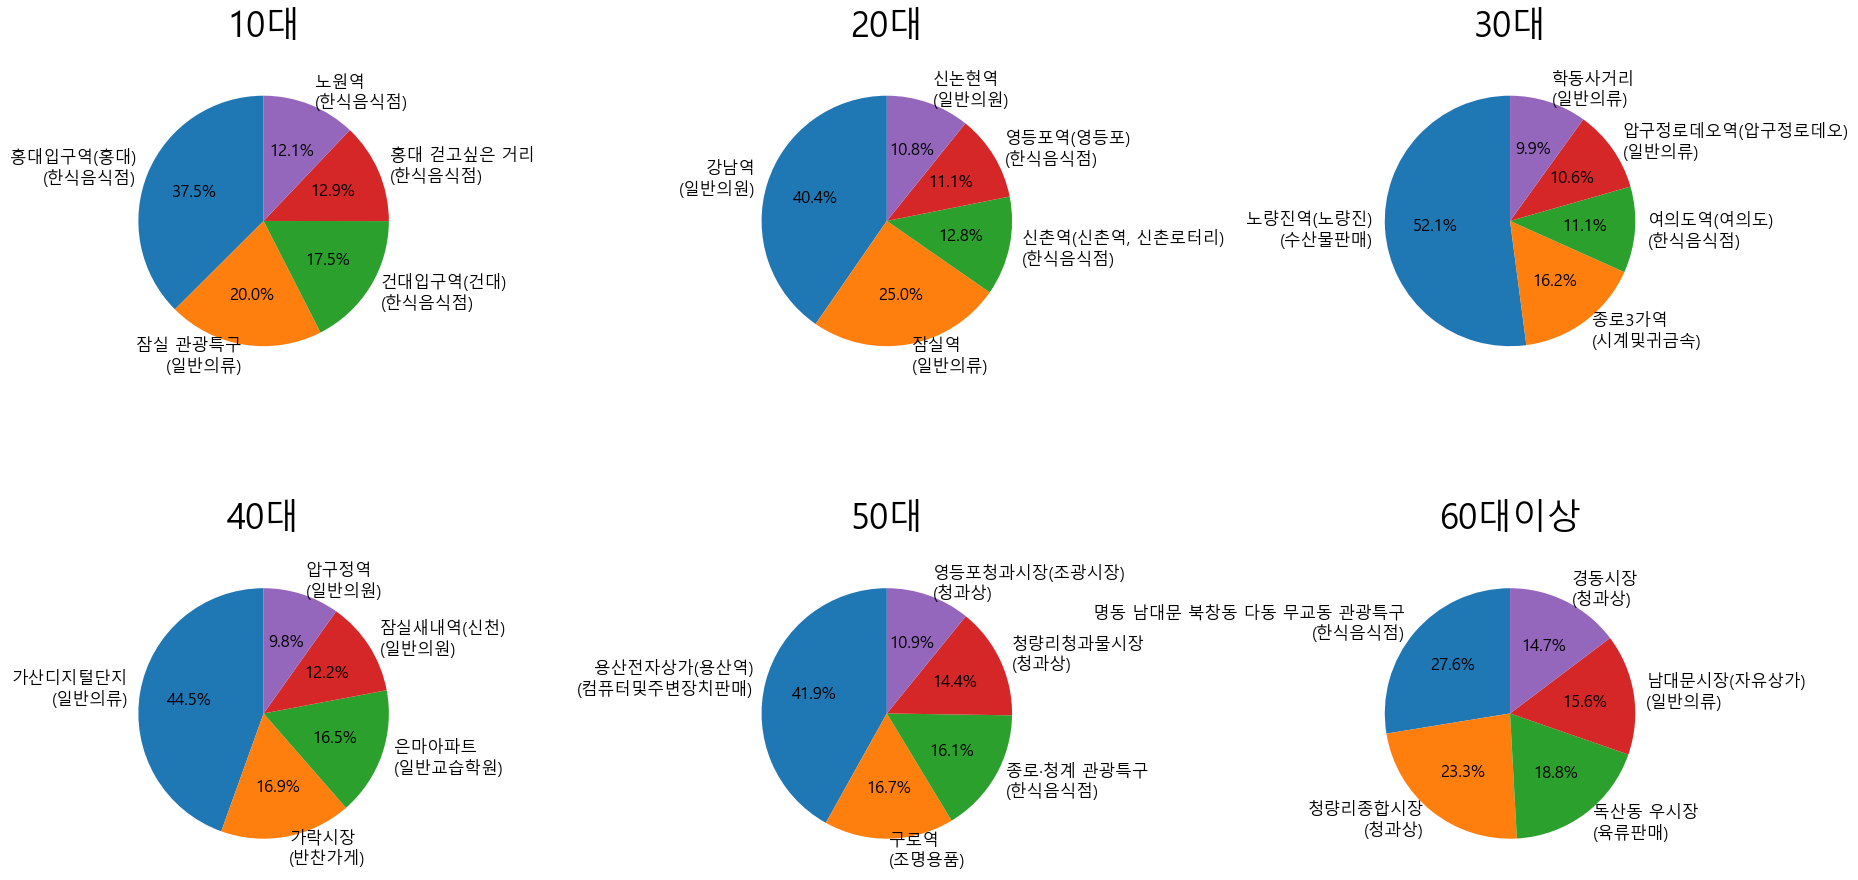

In [3]:
# 한글 폰트 설정 
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

# CSV에서 불러온 dfs 딕셔너리를 기반으로 개별 데이터 할당
day_pop  = dfs['street']
res_pop  = dfs['resident']
wrk_pop  = dfs['worker']
attr_fac = dfs['attract']
sales    = dfs['sales']

# PCA를 위한 데이터 병합
day_subset   = day_pop[['기준_년분기_코드', '상권_코드_명', '총_유동인구_수']]
res_subset   = res_pop[['기준_년분기_코드', '상권_코드_명', '총_상주인구_수']]
wrk_subset   = wrk_pop[['기준_년분기_코드', '상권_코드_명', '총_직장_인구_수']]
attr_subset  = attr_fac[['기준_년분기_코드', '상권_코드_명', '집객시설_수']]
sales_subset = sales[['기준_년분기_코드', '상권_코드_명', '당월_매출_금액']]

df_merge_pca = (
    day_subset
    .merge(res_subset,   on=['기준_년분기_코드','상권_코드_명'], how='inner')
    .merge(wrk_subset,   on=['기준_년분기_코드','상권_코드_명'], how='inner')
    .merge(attr_subset,  on=['기준_년분기_코드','상권_코드_명'], how='inner')
    .merge(sales_subset, on=['기준_년분기_코드','상권_코드_명'], how='inner')
)
if df_merge_pca.empty:
    raise ValueError("병합 결과가 빈 DataFrame입니다. 파일 간 키가 일치하는 데이터가 없습니다.")

# PCA 입력 변수 선택 및 결측치 처리
features = ['총_유동인구_수','총_상주인구_수','총_직장_인구_수','집객시설_수','당월_매출_금액']
X = df_merge_pca[features].fillna(0)

# 표준화 및 PCA 수행 (주성분 2개 추출)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)
pca_model = PCA(n_components=2)
pcs       = pca_model.fit_transform(X_scaled)

# PCA 결과 DataFrame 결합 및 combined_pca 계산
df_pca = pd.DataFrame(pcs, columns=['PC1','PC2'])
df_pca = pd.concat(
    [df_merge_pca[['기준_년분기_코드','상권_코드_명']].reset_index(drop=True), df_pca],
    axis=1
)
df_pca['combined_pca'] = df_pca['PC1'] + df_pca['PC2']

# 상권별로 최대 combined_pca 선택
max_pca = df_pca.groupby('상권_코드_명', as_index=False)['combined_pca'].max() # 최상위 업종 추출을 위한 max()

# 연령대별 매출 합계 집계 (상권별)
age_cols  = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
             '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
age_sales = sales.groupby('상권_코드_명')[age_cols].sum().reset_index()

# 상권별 최상위 업종 계산 (전체 매출 기준)
industry_sales = (
    sales
    .groupby(['상권_코드_명','서비스_업종_코드_명'])['당월_매출_금액']
    .sum()
    .reset_index()
)
top_industry = (
    industry_sales
    .sort_values(['상권_코드_명','당월_매출_금액'], ascending=[True,False])
    .groupby('상권_코드_명')
    .first()
    .reset_index()[['상권_코드_명','서비스_업종_코드_명']]
)

# 연령대별 후보 상권 리스트 생성 (매출 기준 내림차순)
age_groups = {
    '10대':     '연령대_10_매출_금액',
    '20대':     '연령대_20_매출_금액',
    '30대':     '연령대_30_매출_금액',
    '40대':     '연령대_40_매출_금액',
    '50대':     '연령대_50_매출_금액',
    '60대이상':  '연령대_60_이상_매출_금액'
}
candidates = {}
for age, col in age_groups.items():
    candidates[age] = age_sales.sort_values(col, ascending=False)['상권_코드_명'].tolist()

# 중복 없이 상권 5개씩 배정 준비
assigned = {} 
results  = {age: [] for age in age_groups}
pointers = {age: 0   for age in age_groups}

# 각 연령대별 고유 상권 5개 배정 루프
while any(len(results[age]) < 5 for age in age_groups):
    for age in age_groups:
        if len(results[age]) >= 5:
            continue
        while True:
            idx = pointers[age]
            if idx >= len(candidates[age]):
                break

            district = candidates[age][idx]
            pointers[age] += 1

            match = max_pca[max_pca['상권_코드_명'] == district]
            if not match.empty:
                pca_score = match['combined_pca'].values[0]
            else:
                pca_score = -np.inf

            if district in assigned:
                # 이미 다른 연령대에 배정되었으면, PCA 점수 비교
                prev_age   = assigned[district]
                prev_match = max_pca[max_pca['상권_코드_명'] == district]
                prev_score = prev_match['combined_pca'].values[0] if not prev_match.empty else -np.inf
                if pca_score > prev_score:
                    # 더 높은 PCA 점수를 가진 연령대로 재배정
                    results[prev_age].remove(district)
                    assigned[district] = age
                    results[age].append(district)
                    break
                else:
                    # 현재 연령대에서는 스킵
                    continue
            else:
                # 아직 배정되지 않은 상권이면 바로 배정
                assigned[district] = age
                results[age].append(district)
                break

# 최종 상권 리스트 및 연령별 매출값, 최상위 업종 조회
final_rows = []
for age, districts in results.items():
    for district in districts:
        sales_col   = age_groups[age]
        sales_value = age_sales.loc[age_sales['상권_코드_명'] == district, sales_col].values
        sales_value = sales_value[0] if len(sales_value) > 0 else 0

        industry_match = top_industry[top_industry['상권_코드_명'] == district]
        industry = industry_match['서비스_업종_코드_명'].values[0] if not industry_match.empty else np.nan

        final_rows.append({
            '연령대': age,
            '상권_코드_명': district,
            '최상위_업종': industry,
            '연령별_매출값': sales_value
        })

df_final_distinct = pd.DataFrame(final_rows)

# 연령대별 파이 차트: 2행 × 3열 한 화면에 그리기 
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))   
axes = axes.flatten()                                          

for idx, (age, group_df) in enumerate(df_final_distinct.groupby('연령대')):
    ax = axes[idx]   # 이번 파이를 그릴 축 선택

    # 레이블: “상권 (최상위업종)”
    labels = [
        f"{row['상권_코드_명']}\n({row['최상위_업종']})"
        for _, row in group_df.iterrows()
    ]

    raw_sizes = group_df['연령별_매출값'].fillna(0).tolist()
    min_val   = min(raw_sizes)
    sizes     = [s + abs(min_val) if min_val < 0 else s for s in raw_sizes]

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        radius=1
    )

    ax.set_title(f"{age}", fontsize=25, pad=20)
    ax.set_aspect('equal')          
    for txt in texts + autotexts:   
        txt.set_fontsize(12)

# 2×3보다 상권(연령대)이 적을 때 남는 축 제거
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


연령대별 TOP5 상권과 해당 상권 최상위 업종 지도 시각화

In [4]:
# 데이터 불러오기 
area_df  = dfs['area']

# 상권별 최상위 업종 
industry_sales = (
    sales
    .groupby(['상권_코드_명','서비스_업종_코드_명'])['당월_매출_금액']
    .sum()
    .reset_index()
)
top_industry = (
    industry_sales
    .sort_values(['상권_코드_명','당월_매출_금액'], ascending=[True,False])
    .groupby('상권_코드_명')
    .first()
    .reset_index()[['상권_코드_명','서비스_업종_코드_명']]
)

# 연령대별 후보 상권 리스트 생성 
age_groups = {
    '10대':     '연령대_10_매출_금액',
    '20대':     '연령대_20_매출_금액',
    '30대':     '연령대_30_매출_금액',
    '40대':     '연령대_40_매출_금액',
    '50대':     '연령대_50_매출_금액',
    '60대이상':  '연령대_60_이상_매출_금액'
}
candidates = {
    age: age_sales.sort_values(col, ascending=False)['상권_코드_명'].tolist()
    for age, col in age_groups.items()
}

# 중복 없이 상권 5개씩 배정 
assigned = {}
results  = {age: [] for age in age_groups}
pointers = {age: 0   for age in age_groups}

while any(len(results[age]) < 5 for age in age_groups):
    for age in age_groups:
        if len(results[age]) >= 5:
            continue
        while True:
            idx = pointers[age]
            if idx >= len(candidates[age]):
                break
            district = candidates[age][idx]
            pointers[age] += 1

            match = max_pca[max_pca['상권_코드_명'] == district]
            pca_score = match['combined_pca'].values[0] if not match.empty else -np.inf

            if district in assigned:
                prev_age   = assigned[district]
                prev_match = max_pca[max_pca['상권_코드_명'] == district]
                prev_score = prev_match['combined_pca'].values[0] if not prev_match.empty else -np.inf
                if pca_score > prev_score:
                    results[prev_age].remove(district)
                    assigned[district] = age
                    results[age].append(district)
                    break
                else:
                    continue
            else:
                assigned[district] = age
                results[age].append(district)
                break

# 최종 df_final_distinct 생성 
final_rows = []
for age, districts in results.items():
    for district in districts:
        sales_col   = age_groups[age]
        sales_val   = age_sales.loc[
            age_sales['상권_코드_명'] == district, 
            sales_col
        ].values
        sales_val   = sales_val[0] if len(sales_val)>0 else 0

        industry_match = top_industry[
            top_industry['상권_코드_명'] == district
        ]
        industry       = (
            industry_match['서비스_업종_코드_명'].values[0]
            if not industry_match.empty else np.nan
        )

        final_rows.append({
            '연령대': age,
            '상권_코드_명': district,
            '최상위_업종': industry,
            '연령별_매출값': sales_val
        })

df_final_distinct = pd.DataFrame(final_rows)

# 좌표 변환 (EPSG:5174 → EPSG:4326)
transformer = pyproj.Transformer.from_crs(
    "EPSG:5174", "EPSG:4326", always_xy=True
)
lon_lat = area_df.apply(
    lambda row: transformer.transform(
        row['엑스좌표_값'], row['와이좌표_값']
    ),
    axis=1, result_type='expand'
)
area_df['경도'] = lon_lat[0]
area_df['위도'] = lon_lat[1]
coords_df = area_df[['상권_코드_명', '경도', '위도']]

# 좌표 병합 및 '종로·청계 관광특구' 대체 좌표 지정 
merged = pd.merge(
    df_final_distinct,
    coords_df,
    on='상권_코드_명',
    how='left'
)

# '종로·청계 관광특구' 좌표가 없으면 '종로3가역' 좌표로 대체
mask_tour = merged['상권_코드_명'] == '종로·청계 관광특구'
if mask_tour.any():
    replace_row = coords_df[coords_df['상권_코드_명'] == '종로3가역']
    if not replace_row.empty:
        lat_rep = float(replace_row['위도'].values[0])
        lon_rep = float(replace_row['경도'].values[0])
        merged.loc[mask_tour, '위도'] = lat_rep
        merged.loc[mask_tour, '경도'] = lon_rep

na_rows = merged[
    merged['위도'].isna() | merged['경도'].isna()
]
if not na_rows.empty:
    print("좌표 정보가 없어 지도에서 제외된 상권들:\n",
          na_rows['상권_코드_명'].tolist())
merged = merged.dropna(subset=['위도','경도']).reset_index(drop=True)

# 연령대별 색상 매핑 
color_map = {
    '10대': 'red',
    '20대': 'blue',
    '30대': 'green',
    '40대': 'purple',
    '50대': 'orange',
    '60대이상': 'darkred'
}
merged['color'] = merged['연령대'].map(color_map)

# Folium 지도 생성 및 화살표 마커 추가 
center_lat, center_lon = merged[['위도','경도']].mean().values
m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

for _, row in merged.iterrows():
    folium.Marker(
        location=[row['위도'], row['경도']],
        popup=folium.Popup(
            f"<b>{row['상권_코드_명']}</b><br>"
            f"업종: {row['최상위_업종']}<br>"
            f"매출: {int(row['연령별_매출값']):,}",
            max_width=250
        ),
        icon=folium.Icon(
            color=row['color'],
            icon='info-sign',
            prefix='fa'
        )
    ).add_to(m)


# 연령대별 색상 매핑 
color_map = {
    '10대': 'red',
    '20대': 'blue',
    '30대': 'green',
    '40대': 'purple',
    '50대': 'orange',
    '60대이상': 'darkred'
}

# 지도 왼쪽 상단에 고정될 HTML/CSS 툴팁 코드
legend_left = '''
    <div style="
        position: fixed; 
        top: 50px; left: 100px; 
        width: 160px; 
        background-color: white;
        border:2px solid grey; 
        z-index:9999; 
        padding: 10px; 
        font-size:14px;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    ">
      <div style="font-weight:bold; margin-bottom:6px;">===연령대별 색상===</div>
      <div style="margin-bottom:4px;">
        <span style="display:inline-block; width:12px; height:12px; background:red; border-radius:50%;"></span>&nbsp;10대
      </div>
      <div style="margin-bottom:4px;">
        <span style="display:inline-block; width:12px; height:12px; background:blue; border-radius:50%;"></span>&nbsp;20대
      </div>
      <div style="margin-bottom:4px;">
        <span style="display:inline-block; width:12px; height:12px; background:green; border-radius:50%;"></span>&nbsp;30대
      </div>
      <div style="margin-bottom:4px;">
        <span style="display:inline-block; width:12px; height:12px; background:purple; border-radius:50%;"></span>&nbsp;40대
      </div>
      <div style="margin-bottom:4px;">
        <span style="display:inline-block; width:12px; height:12px; background:orange; border-radius:50%;"></span>&nbsp;50대
      </div>
      <div>
        <span style="display:inline-block; width:12px; height:12px; background:darkred; border-radius:50%;"></span>&nbsp;60대이상
      </div>
    </div>
'''

# 지도 왼쪽 상단에 HTML 툴팁을 추가
m.get_root().html.add_child(folium.Element(legend_left))


# 지도 오른쪽 상단에 고정될 HTML/CSS 툴팁 코드
tooltip_html = '''
    <div style="
        position: fixed; 
        top: 50px; right: 50px; 
        width: 250px; max-height: 450px; 
        overflow-y: auto; 
        border:2px solid #444; 
        background-color:#f9f9f9; 
        padding: 5px; 
        z-index:9999; 
        font-size:12px; 
        box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    ">
      <div style="
          font-weight:bold; 
          font-size:15px; 
          margin-bottom:8px;
          display:flex; 
          align-items:center;
      ">
        
       연령대별 PCA 주성분 상권 TOP 5
        
      </div>
'''
info_df = pd.merge(
    df_final_distinct,
    max_pca,
    on='상권_코드_명',
    how='left'
)

for age in age_groups.keys():
    dot_color = color_map[age]
    tooltip_html += f'''
      <div style="margin-top:6px; font-weight:bold; color:{dot_color};">{age}</div>
      <ul style="margin-top:4px; margin-left:12px; padding-left:0px;">
    '''
    subset = info_df[info_df['연령대'] == age]
    for _, row in subset.iterrows():
        score = row['combined_pca']
        tooltip_html += f'''
        <li style="margin-bottom:6px; list-style:none;">
          <span style="font-size:12px;">●</span>
          <span style="font-weight:bold;"> {row["상권_코드_명"]}</span><br>
          <span style="font-size:12px; margin-left:14px;">연령대-업종: {row["연령대"]} - {row["최상위_업종"]}</span><br>
          <span style="font-size:12px; margin-left:14px;">점수: {score:.2f}</span>
        </li>
        '''
    tooltip_html += '</ul>'

tooltip_html += '</div>'

# 지도 오른쪽 상단에 HTML 툴팁을 추가
m.get_root().html.add_child(folium.Element(tooltip_html))

# 지도 저장 및 출력
m.save("HTML_연령대별 TOP5 상권과 해당 상권 최상위 업종 지도 시각화.html")
m


성장세 분석을 위한 분기별 필터링

1. 총 매출 합산

In [5]:
# 인코딩 자동 감지 함수
def detect_encoding(path):
    with open(path, 'rb') as f:
        return chardet.detect(f.read(10000))['encoding']

# 파일 경로 정의
file_paths = {
    '2021': './Original_data/서울시 상권분석서비스(추정매출-상권)_2021년.csv',
    '2022': './Original_data/서울시 상권분석서비스(추정매출-상권)_2022년.csv',
    '2023': './Original_data/서울시 상권분석서비스(추정매출-상권)_2023년.csv',
    '2024': './Original_data/서울시 상권분석서비스(추정매출-상권)_2024년.csv'
}

# 파일별 읽기 (인코딩 감지 포함) → dfs_list로 이름 변경
dfs_list = []
for path in file_paths.values():
    enc = detect_encoding(path)
    df = pd.read_csv(path, encoding=enc)
    dfs_list.append(df)

# 데이터 병합
df_all = pd.concat(dfs_list, ignore_index=True)

# 연도/분기 분리
df_all['기준_년분기_코드'] = df_all['기준_년분기_코드'].astype(str)
df_all['년도'] = df_all['기준_년분기_코드'].str[:4]
df_all['분기'] = df_all['기준_년분기_코드'].str[4:]

# 매출 합산 (년도, 분기, 상권명 기준)
df_grouped = df_all.groupby(['년도', '분기', '상권_코드_명'], as_index=False)['당월_매출_금액'].sum()

# 저장 폴더 생성
output_dir = './filtered'
os.makedirs(output_dir, exist_ok=True)

# 결과 저장
output_path = os.path.join(output_dir, '상권별_년도_분기별_총매출_2021_2024.csv')
df_grouped.to_csv(output_path, index=False, encoding='utf-8-sig')

# 결과 출력
print("✅ 저장 완료:", output_path)

✅ 저장 완료: ./filtered\상권별_년도_분기별_총매출_2021_2024.csv


2. 최종 분기별 데이터 합산

In [6]:
import pandas as pd
import chardet
import os

# 인코딩 자동 감지 함수
def detect_encoding(path):
    with open(path, 'rb') as f:
        result = chardet.detect(f.read(10000))
        return result['encoding'] or 'cp949'  # 예외 방지용

# 저장 폴더 확인
output_dir = "./filtered"
os.makedirs(output_dir, exist_ok=True)

# 파일 경로 정의
매출_파일 = os.path.join(output_dir, "상권별_년도_분기별_총매출_2021_2024.csv")
파일_경로들 = {
    '길단위': "./Original_data/서울시 상권분석서비스(길단위인구-상권).csv",
    '집객시설': "./Original_data/서울시 상권분석서비스(집객시설-상권).csv",
    '직장인구': "./Original_data/서울시 상권분석서비스(직장인구-상권).csv",
    '상주인구': "./Original_data/서울시 상권분석서비스(상주인구-상권).csv"
}

# 1. 매출 데이터 불러오기 (utf-8-sig 고정)
df_매출 = pd.read_csv(매출_파일, encoding='utf-8-sig')

# 2. 기타 파일들 불러오기 (인코딩 자동 감지)
df_길단위 = pd.read_csv(파일_경로들['길단위'], encoding=detect_encoding(파일_경로들['길단위']))
df_집객 = pd.read_csv(파일_경로들['집객시설'], encoding=detect_encoding(파일_경로들['집객시설']))
df_직장 = pd.read_csv(파일_경로들['직장인구'], encoding=detect_encoding(파일_경로들['직장인구']))
df_상주 = pd.read_csv(파일_경로들['상주인구'], encoding=detect_encoding(파일_경로들['상주인구']))

# 🧹 3. 공통 전처리 함수
def preprocess(df, value_column_name):
    df['기준_년분기_코드'] = df['기준_년분기_코드'].astype(str)
    df['년도'] = df['기준_년분기_코드'].str[:4]
    df['분기'] = df['기준_년분기_코드'].str[4:]
    return df.groupby(['년도', '분기', '상권_코드_명'], as_index=False)[value_column_name].sum()

# 4. 각 데이터 요약
df_길단위_요약 = preprocess(df_길단위, '총_유동인구_수')
df_집객_요약 = preprocess(df_집객, '집객시설_수')
df_직장_요약 = preprocess(df_직장, '총_직장_인구_수')
df_상주_요약 = preprocess(df_상주, '총_상주인구_수')

# 5. 매출 데이터의 '년도', '분기' 컬럼 문자열 처리
df_매출['년도'] = df_매출['년도'].astype(str)
df_매출['분기'] = df_매출['분기'].astype(str)

# 6. 병합
df_통합 = df_매출.copy()
df_통합 = df_통합.merge(df_길단위_요약, on=['년도', '분기', '상권_코드_명'], how='left')
df_통합 = df_통합.merge(df_집객_요약, on=['년도', '분기', '상권_코드_명'], how='left')
df_통합 = df_통합.merge(df_직장_요약, on=['년도', '분기', '상권_코드_명'], how='left')
df_통합 = df_통합.merge(df_상주_요약, on=['년도', '분기', '상권_코드_명'], how='left')

# 7. 저장
output_path = os.path.join(output_dir, "상권별_년도_분기별_통합데이터_2021_2024.csv")
df_통합.to_csv(output_path, index=False, encoding='utf-8-sig')

# 완료 메시지
print("✅ 병합 완료! 생성된 파일:", output_path)

✅ 병합 완료! 생성된 파일: ./filtered\상권별_년도_분기별_통합데이터_2021_2024.csv


연도별 상권 성장세 분석

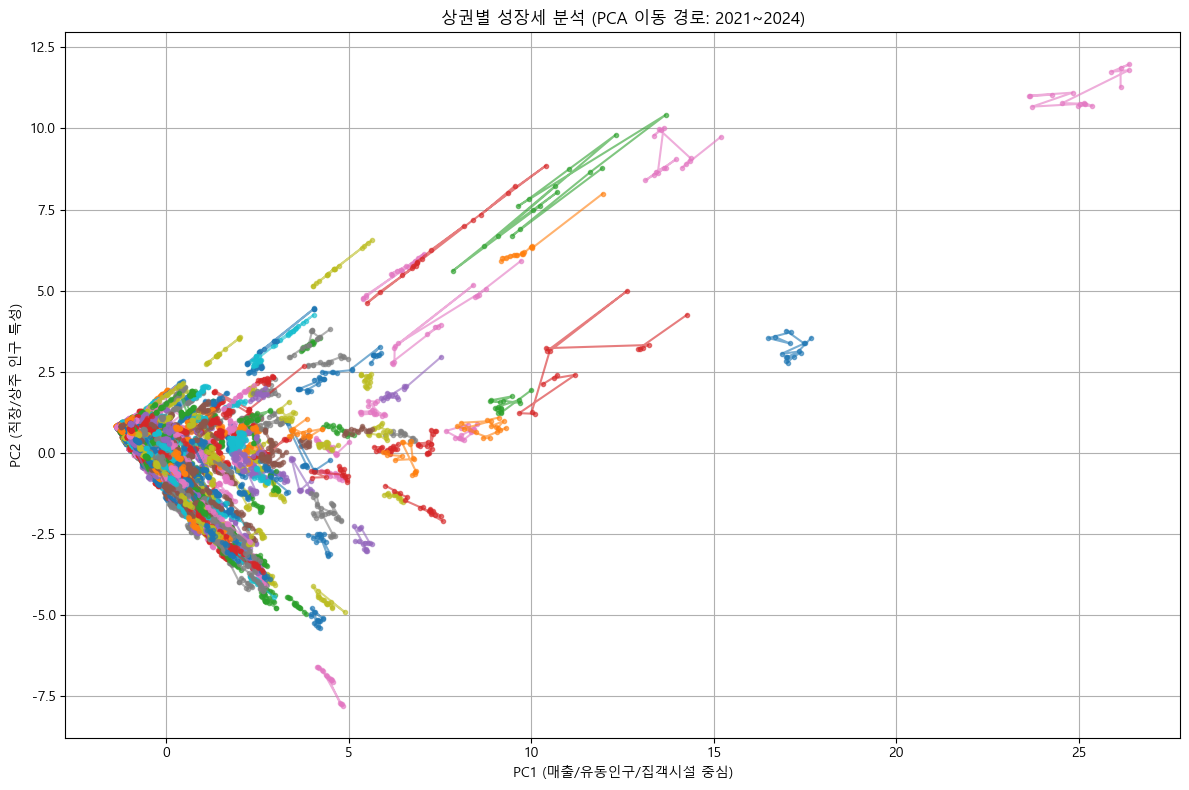

In [7]:
# 🔤 한글 폰트 설정 (Windows: 맑은 고딕, macOS: AppleGothic)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 데이터 불러오기
df = pd.read_csv('./filtered/상권별_년도_분기별_통합데이터_2021_2024.csv', encoding='utf-8-sig')

# 2. 분석에 필요한 열 정의
features = ['당월_매출_금액', '총_유동인구_수', '집객시설_수', '총_직장_인구_수', '총_상주인구_수']

# 3. 결측치 처리: 각 '년도' 그룹별 평균으로 대체
for col in features:
    df[col] = df.groupby('년도')[col].transform(lambda x: x.fillna(x.mean()))

# 4. 정규화
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. PCA 수행
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 6. 결과 병합
df_pca = df[['년도', '분기', '상권_코드_명']].copy()
# PC1 방향 고정
if X_pca[:, 0].mean() < 0:
    df_pca['PC1'] = -X_pca[:, 0]
else:
    df_pca['PC1'] = X_pca[:, 0]

# PC2 방향 고정
if X_pca[:, 1].mean() < 0:
    df_pca['PC2'] = -X_pca[:, 1]
else:
    df_pca['PC2'] = X_pca[:, 1]

# 7. 상권별 PCA 이동 시각화
plt.figure(figsize=(12, 8))
for name, group in df_pca.groupby('상권_코드_명'):
    group = group.sort_values(by=['년도', '분기'])
    plt.plot(group['PC1'], group['PC2'], marker='o', markersize=3, alpha=0.6)

plt.title("상권별 성장세 분석 (PCA 이동 경로: 2021~2024)")
plt.xlabel("PC1 (매출/유동인구/집객시설 중심)")
plt.ylabel("PC2 (직장/상주 인구 특성)")
plt.grid(True)
plt.tight_layout()
plt.savefig("상권_PCA_성장세_시각화.png", dpi=300)
plt.show()

상권 성장세 상위 10개 시각화

C:\Users\shs86\AppData\Local\Temp\ipykernel_8444\3728193238.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  movement = df_pca.groupby('상권_코드_명').apply(compute_movement)


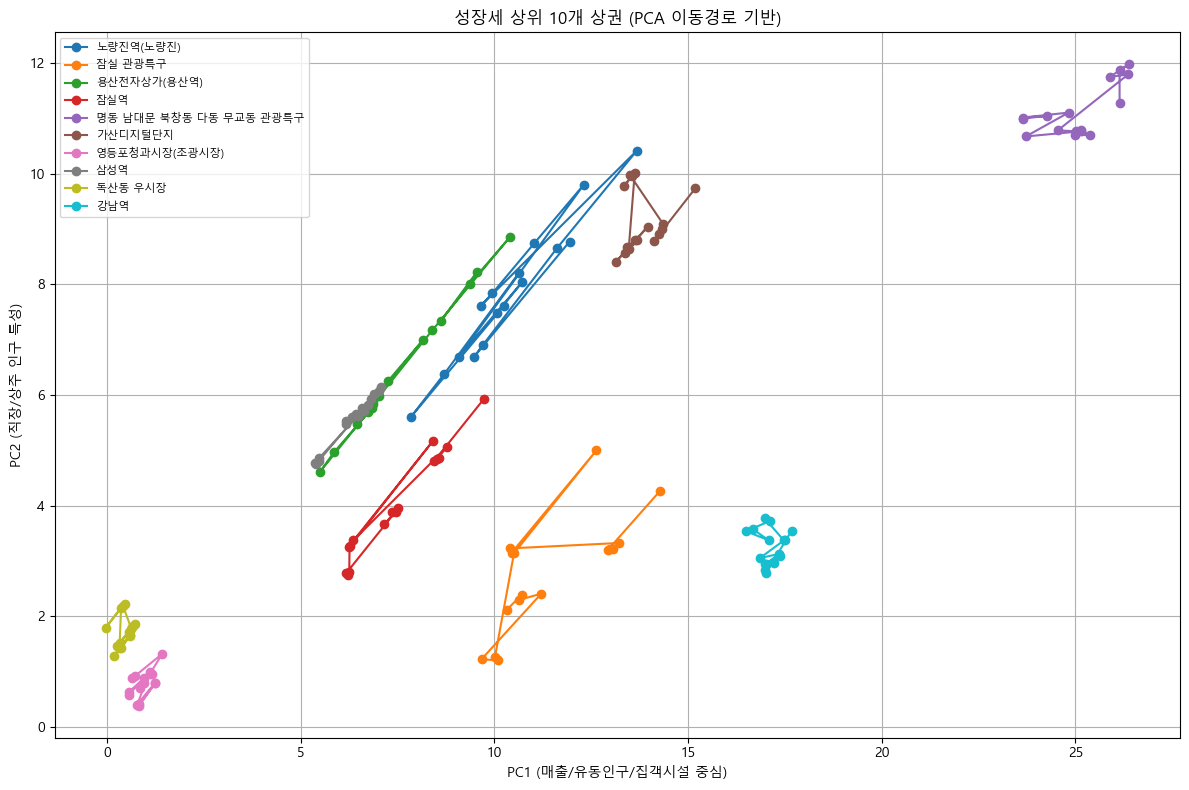

In [8]:
# 1. 상권별 이동 거리 계산 함수
def compute_movement(group):
    group = group.sort_values(by=['년도', '분기'])
    dx = np.diff(group['PC1'])
    dy = np.diff(group['PC2'])
    return np.sum(np.sqrt(dx**2 + dy**2))

# 2. 이동량 계산 및 상위 10개 상권 추출
movement = df_pca.groupby('상권_코드_명').apply(compute_movement)
top_10 = movement.sort_values(ascending=False).head(10).index.tolist()

# 3. 시각화: 성장세 상위 10개 상권
plt.figure(figsize=(12, 8))
for name in top_10:
    group = df_pca[df_pca['상권_코드_명'] == name].sort_values(by=['년도', '분기'])
    plt.plot(group['PC1'], group['PC2'], marker='o', label=name)

plt.title("성장세 상위 10개 상권 (PCA 이동경로 기반)")
plt.xlabel("PC1 (매출/유동인구/집객시설 중심)")
plt.ylabel("PC2 (직장/상주 인구 특성)")
plt.legend(loc='best', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig("성장세_상위10개_상권_PCA_이동경로.png", dpi=300)
plt.show()

상위 업종 TOP 30 추출

In [10]:
# 1. 업종별 총 매출과 점포 수 집계
sales_sum = dfs['sales'].groupby('서비스_업종_코드_명')['당월_매출_금액'].sum().reset_index()
store_sum = dfs['store'].groupby('서비스_업종_코드_명')['점포_수'].sum().reset_index()

# 2. 병합
combined = pd.merge(sales_sum, store_sum, on='서비스_업종_코드_명')

# 3. 정규화
combined['매출_정규화'] = (
    (combined['당월_매출_금액'] - combined['당월_매출_금액'].min()) /
    (combined['당월_매출_금액'].max() - combined['당월_매출_금액'].min())
)

combined['점포수_정규화'] = (
    (combined['점포_수'] - combined['점포_수'].min()) /
    (combined['점포_수'].max() - combined['점포_수'].min())
)

# 4. 종합 점수 계산 (동일 가중치)
combined['종합점수'] = (combined['매출_정규화'] + combined['점포수_정규화']) / 2

# 5. Top 30 업종 추출
top_industries = combined.sort_values(by='종합점수', ascending=False).head(30)['서비스_업종_코드_명'].tolist()

# 6. 결과 출력
print("상위 30개 업종:")
print(top_industries)

상위 30개 업종:
['한식음식점', '일반의류', '일반의원', '부동산중개업', '커피-음료', '의약품', '호프-간이주점', '일반교습학원', '수산물판매', '청과상', '슈퍼마켓', '반찬가게', '미용실', '화장품', '컴퓨터및주변장치판매', '육류판매', '조명용품', '편의점', '전자상거래업', '양식음식점', '분식전문점', '치과의원', '시계및귀금속', '일식음식점', '중식음식점', '예술학원', '제과점', '피부관리실', '스포츠 강습', '문구']


상위 상권 TOP 15 추출

In [11]:
# 병합 (sales + store)
sales_trim = dfs['sales'][['상권_코드', '상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액']]
store_trim = dfs['store'][['상권_코드', '서비스_업종_코드_명', '점포_수']]
merged = pd.merge(sales_trim, store_trim, on=['상권_코드', '서비스_업종_코드_명'])
merged['점포당_평균_매출'] = merged['당월_매출_금액'] / merged['점포_수']

# base 데이터 설정
base = merged[['상권_코드', '상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액', '점포_수', '점포당_평균_매출']]

# 상권 변수 병합
income_trim = dfs['income'][['상권_코드', '월_평균_소득_금액']].rename(columns={'월_평균_소득_금액': '총_소득금액'})
worker_trim = dfs['worker'][['상권_코드', '총_직장_인구_수']].rename(columns={'총_직장_인구_수': '직장_인구_수'})
attract_trim = dfs['attract'][['상권_코드', '집객시설_수']]
flow_trim = dfs['street'][['상권_코드', '총_유동인구_수']]
resident_trim = dfs['resident'][['상권_코드', '총_상주인구_수']]
trend_trim = dfs['change'][['상권_코드', '상권_변화_지표']]

# 중복 제거
for df in [income_trim, worker_trim, attract_trim, flow_trim, resident_trim, trend_trim]:
    df.drop_duplicates(subset='상권_코드', inplace=True)

# 병합
df_full = base.merge(income_trim, on='상권_코드', how='left') \
              .merge(worker_trim, on='상권_코드', how='left') \
              .merge(attract_trim, on='상권_코드', how='left') \
              .merge(flow_trim, on='상권_코드', how='left') \
              .merge(resident_trim, on='상권_코드', how='left') \
              .merge(trend_trim, on='상권_코드', how='left')

# 정규화 및 종합 점수
df_full['상권_변화_지표'] = pd.to_numeric(df_full['상권_변화_지표'], errors='coerce')

for col, new_col in [
    ('당월_매출_금액', '매출_정규화'),
    ('점포_수', '점포수_정규화'),
    ('총_소득금액', '소득_정규화'),
    ('직장_인구_수', '직장인구_정규화'),
    ('집객시설_수', '집객시설_정규화'),
    ('총_유동인구_수', '유동인구_정규화'),
    ('총_상주인구_수', '상주인구_정규화'),
    ('상권_변화_지표', '상권지표_정규화')
]:
    df_full[new_col] = (df_full[col] - df_full[col].min()) / (df_full[col].max() - df_full[col].min())

df_full['종합_점수'] = df_full[[
    '매출_정규화',
    '점포수_정규화',
    '소득_정규화',
    '직장인구_정규화',
    '집객시설_정규화',
    '유동인구_정규화',
    '상주인구_정규화',
    '상권지표_정규화'
]].mean(axis=1)

C:\Users\shs86\AppData\Local\Temp\ipykernel_8444\1892902697.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(subset='상권_코드', inplace=True)


In [12]:
# 1. 상권별 종합점수 평균 계산 (업종 상관없이 상권 단위로)
area_scores = (
    df_full
    .groupby('상권_코드')[[
        '매출_정규화',
        '점포수_정규화',
        '소득_정규화',
        '직장인구_정규화',
        '집객시설_정규화',
        '유동인구_정규화',
        '상주인구_정규화',
        '상권지표_정규화'
    ]]
    .mean()
)

# 2. 종합 점수 계산
area_scores['종합점수'] = area_scores.mean(axis=1)

# 3. 종합 점수 기준 상위 15개 상권코드 추출
top15_areas = area_scores.sort_values(by='종합점수', ascending=False).head(15).index.tolist()

# 4. 결과 출력
print("종합점수 기준 상위 15개 상권코드 (업종 무관, 고정용)")
print(top15_areas)

종합점수 기준 상위 15개 상권코드 (업종 무관, 고정용)
[3001492, 3120189, 3001495, 3001494, 3120149, 3120197, 3120173, 3110659, 3120210, 3120227, 3120114, 3120094, 3110656, 3110544, 3120215]


데이터 병합 과정

In [13]:
# 1. sales와 store 데이터에서 필요한 컬럼만 추출
sales_trim = dfs['sales'][['상권_코드', '상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액']]
store_trim = dfs['store'][['상권_코드', '서비스_업종_코드_명', '점포_수']]

# 2. top30 업종 + top15 상권 기준 필터링
sales_filtered = sales_trim[
    sales_trim['서비스_업종_코드_명'].isin(top_industries) &
    sales_trim['상권_코드'].isin(top15_areas)
]
store_filtered = store_trim[
    store_trim['서비스_업종_코드_명'].isin(top_industries) &
    store_trim['상권_코드'].isin(top15_areas)
]

# 3. 병합
merged = pd.merge(
    sales_filtered,
    store_filtered,
    on=['상권_코드', '서비스_업종_코드_명'],
    how='inner'
)

# 4. 점포당 평균 매출 계산
merged['점포당_평균_매출'] = merged['당월_매출_금액'] / merged['점포_수']

# 5. 결과 출력
print("✅ 병합 완료 | shape:", merged.shape)
display(merged.head())

✅ 병합 완료 | shape: (5684, 6)


,상권_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,점포_수,점포당_평균_매출
0,3110544,망리단길,한식음식점,5218888395,98,5.325396e+07
1,3110544,망리단길,한식음식점,5218888395,104,5.018162e+07
2,3110544,망리단길,한식음식점,5218888395,104,5.018162e+07
3,3110544,망리단길,한식음식점,5218888395,108,4.832304e+07
4,3110544,망리단길,중식음식점,52469111,7,7.495587e+06


In [14]:
# 병합 대상 상권 단위 데이터 전처리
income_trim = dfs['income'][['상권_코드', '월_평균_소득_금액']].rename(columns={'월_평균_소득_금액': '총_소득금액'})
worker_trim = dfs['worker'][['상권_코드', '총_직장_인구_수']].rename(columns={'총_직장_인구_수': '직장_인구_수'})
attract_trim = dfs['attract'][['상권_코드', '집객시설_수']]
flow_trim = dfs['street'][['상권_코드', '총_유동인구_수']]
resident_trim = dfs['resident'][['상권_코드', '총_상주인구_수']]
trend_trim = dfs['change'][['상권_코드', '상권_변화_지표_명']]
area_trim = dfs['area'][['상권_코드', '영역_면적']]


# 폐업률 → 비율로 변환
closure_trim = dfs['store'][['상권_코드', '폐업_률']].copy()
closure_trim['폐업_률'] = 1-(closure_trim['폐업_률'] / 100)

# 파생변수를 위한 세부적 컬럼 추가
similar_trim = dfs['store'][['상권_코드', '유사_업종_점포_수']]
new_trim = dfs['store'][['상권_코드', '개업_율']].copy()
new_trim['개업_율'] = 1- (new_trim['개업_율'] / 100)
frequency_trim = dfs['sales'][['상권_코드', '당월_매출_건수']]
expense_trim = dfs['income'][['상권_코드', '지출_총금액']]

# 중복 제거
for df in [income_trim, worker_trim, attract_trim, flow_trim, resident_trim, trend_trim, area_trim,
           closure_trim, similar_trim, new_trim, frequency_trim, expense_trim]:
    df.drop_duplicates(subset='상권_코드', inplace=True)

# 병합 수행
df_full = (
    merged
    .merge(income_trim, on='상권_코드', how='left')
    .merge(worker_trim, on='상권_코드', how='left')
    .merge(attract_trim, on='상권_코드', how='left')
    .merge(flow_trim, on='상권_코드', how='left')
    .merge(resident_trim, on='상권_코드', how='left')
    .merge(trend_trim, on='상권_코드', how='left')
    .merge(area_trim, on='상권_코드', how='left')
    .merge(closure_trim, on='상권_코드', how='left')
    .merge(similar_trim, on='상권_코드', how='left')
    .merge(new_trim, on='상권_코드', how='left')
    .merge(frequency_trim, on='상권_코드', how='left')
    .merge(expense_trim, on='상권_코드', how='left')
)

print("✅ df_full 생성 완료 | shape:", df_full.shape)
df_full.head()

✅ df_full 생성 완료 | shape: (5684, 18)


C:\Users\shs86\AppData\Local\Temp\ipykernel_8444\3861988921.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(subset='상권_코드', inplace=True)


,상권_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,점포_수,점포당_평균_매출,총_소득금액,직장_인구_수,집객시설_수,총_유동인구_수,총_상주인구_수,상권_변화_지표_명,영역_면적,폐업_률,유사_업종_점포_수,개업_율,당월_매출_건수,지출_총금액
0,3110544,망리단길,한식음식점,5218888395,98,5.325396e+07,2748085.0,1376,50,4999562,11779,다이나믹,311648,0.97,101,0.93,121610,6.703960e+09
1,3110544,망리단길,한식음식점,5218888395,104,5.018162e+07,2748085.0,1376,50,4999562,11779,다이나믹,311648,0.97,101,0.93,121610,6.703960e+09
2,3110544,망리단길,한식음식점,5218888395,104,5.018162e+07,2748085.0,1376,50,4999562,11779,다이나믹,311648,0.97,101,0.93,121610,6.703960e+09
3,3110544,망리단길,한식음식점,5218888395,108,4.832304e+07,2748085.0,1376,50,4999562,11779,다이나믹,311648,0.97,101,0.93,121610,6.703960e+09
4,3110544,망리단길,중식음식점,52469111,7,7.495587e+06,2748085.0,1376,50,4999562,11779,다이나믹,311648,0.97,101,0.93,121610,6.703960e+09


파생 변수 생성

In [15]:
# 파생 변수 생성
df_full['총_생활인구'] = df_full['총_유동인구_수'] + df_full['총_상주인구_수'] + df_full['직장_인구_수']

df_full['인구당_집객시설수'] = df_full['집객시설_수'] / (df_full['총_생활인구'] + 1)
df_full['인구당_지출금액'] = df_full['지출_총금액'] / (df_full['총_생활인구'] + 1)

df_full['소득대비_지출'] = df_full['지출_총금액'] / (df_full['총_소득금액'] + 1)

# 폐업률은 정수형 비율이므로 최대값 기준으로 정규화 (예: 34 → 0.34)
폐업률_최대 = df_full['폐업_률'].max()
df_full['폐업_비율'] = df_full['폐업_률'] / (폐업률_최대 + 1)

# 개업률은 이미 0~1 변환된 상태라고 가정
df_full['순개업률'] = df_full['개업_율'] - df_full['폐업_비율']

df_full['유동_직장_비율'] = df_full['총_유동인구_수'] / (df_full['직장_인구_수'] + 1)
df_full['점포당_거래건수'] = df_full['당월_매출_건수'] / (df_full['점포_수'] + 1)

df_full['유사_업종_비율'] = df_full['유사_업종_점포_수'] / (df_full['점포_수'] + 1)
df_full['유사_업종_경쟁도'] = df_full['유사_업종_점포_수'] / (df_full['총_생활인구'] + 1)

print("✅ 파생 변수 생성 완료 | df_full shape:", df_full.shape)
df_full[[  # 확인용 컬럼 리스트
    '총_생활인구', '인구당_집객시설수', '인구당_지출금액', '소득대비_지출',
    '폐업_비율', '순개업률', '유동_직장_비율', '점포당_거래건수',
    '유사_업종_비율', '유사_업종_경쟁도'
]].head()

✅ 파생 변수 생성 완료 | df_full shape: (5684, 28)


,총_생활인구,인구당_집객시설수,인구당_지출금액,소득대비_지출,폐업_비율,순개업률,유동_직장_비율,점포당_거래건수,유사_업종_비율,유사_업종_경쟁도
0,5012717,0.00001,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1228.383838,1.020202,0.00002
1,5012717,0.00001,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1158.190476,0.961905,0.00002
2,5012717,0.00001,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1158.190476,0.961905,0.00002
3,5012717,0.00001,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1115.688073,0.926606,0.00002
4,5012717,0.00001,1337.390262,2439.501617,0.489899,0.440101,3630.76398,15201.250000,12.625000,0.00002


흥행 여부 기준 설정

In [16]:
# 1. 상위 15개 상권 + 30개 업종으로 필터링
df_filtered = df_full[
    (df_full['상권_코드'].isin(top15_areas)) &
    (df_full['서비스_업종_코드_명'].isin(top_industries))
].copy()

print("▶ 필터링 후 shape:", df_filtered.shape)

# 2. 조합별(상권+업종) 평균 점포당 매출 계산
group_avg = (
    df_filtered
    .groupby(['상권_코드', '서비스_업종_코드_명'])['점포당_평균_매출']
    .mean()
    .reset_index()
    .rename(columns={'점포당_평균_매출': '조합별_평균_매출'})
)

# 3. 병합 (조합별 평균을 원본 데이터에 추가)
df_filtered = pd.merge(df_filtered, group_avg, on=['상권_코드', '서비스_업종_코드_명'], how='left')

# 4. 임계값(threshold) 계산: 전체 조합 평균의 중앙값
threshold = group_avg['조합별_평균_매출'].median()
print("▶ 흥행 기준 (조합 평균의 중앙값):", round(threshold))

# 5. 흥행 여부 정의: 조합 평균이 threshold 이상이면 흥행
df_filtered['흥행_여부'] = (df_filtered['조합별_평균_매출'] >= threshold).astype(int)

# 6. 클래스 분포 확인
print("▶ '흥행_여부' 클래스 분포 (조합 평균 기준):")
print(df_filtered['흥행_여부'].value_counts())

# 7. 인덱스 정리 및 확인
df_filtered.reset_index(drop=True, inplace=True)
df_filtered.head()

▶ 필터링 후 shape: (5684, 28)
▶ 흥행 기준 (조합 평균의 중앙값): 60690469
▶ '흥행_여부' 클래스 분포 (조합 평균 기준):
흥행_여부
1    2900
0    2784
Name: count, dtype: int64


,상권_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,점포_수,점포당_평균_매출,총_소득금액,직장_인구_수,집객시설_수,총_유동인구_수,...,인구당_지출금액,소득대비_지출,폐업_비율,순개업률,유동_직장_비율,점포당_거래건수,유사_업종_비율,유사_업종_경쟁도,조합별_평균_매출,흥행_여부
0,3110544,망리단길,한식음식점,5218888395,98,5.325396e+07,2748085.0,1376,50,4999562,...,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1228.383838,1.020202,0.00002,5.388777e+07,0
1,3110544,망리단길,한식음식점,5218888395,104,5.018162e+07,2748085.0,1376,50,4999562,...,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1158.190476,0.961905,0.00002,5.388777e+07,0
2,3110544,망리단길,한식음식점,5218888395,104,5.018162e+07,2748085.0,1376,50,4999562,...,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1158.190476,0.961905,0.00002,5.388777e+07,0
3,3110544,망리단길,한식음식점,5218888395,108,4.832304e+07,2748085.0,1376,50,4999562,...,1337.390262,2439.501617,0.489899,0.440101,3630.76398,1115.688073,0.926606,0.00002,5.388777e+07,0
4,3110544,망리단길,중식음식점,52469111,7,7.495587e+06,2748085.0,1376,50,4999562,...,1337.390262,2439.501617,0.489899,0.440101,3630.76398,15201.250000,12.625000,0.00002,6.610425e+06,0


In [17]:
# 상권 변화 지표 매핑 사전 정의
change_map = {
    '상권확장': 3,
    '다이나믹': 2,
    '정체': 1,
    '상권축소': 0
}

# 문자형 -> 수치형으로 변환
df_filtered['상권_변화_지표'] = df_filtered['상권_변화_지표_명'].map(change_map)

# 변환된 값 확인
print(df_filtered['상권_변화_지표'].value_counts(dropna=False))

상권_변화_지표
2    3256
1    1704
0     388
3     336
Name: count, dtype: int64


In [18]:
# 1. 사용할 feature 정의
features = [
    '총_생활인구', '인구당_지출금액', '소득대비_지출',
    '인구당_집객시설수', '순개업률', '유사_업종_경쟁도',
    '점포당_거래건수', '상권_변화_지표', '폐업_비율', '유동_직장_비율'
]

# 2. 해당 변수와 타겟만 추출
df_model = df_filtered[features + ['흥행_여부']].copy()

# 3. 결측치 및 이상치 제거
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.dropna(inplace=True)

print("✅ 전처리 후 남은 데이터 수:", len(df_model))

# 4. X, y 분리
X = df_model[features]
y = df_model['흥행_여부']

# 5. 스케일링
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

print("✅ 전처리 및 스케일링 완료 | 최종 샘플 수:", X_scaled.shape[0])

✅ 전처리 후 남은 데이터 수: 5684
✅ 전처리 및 스케일링 완료 | 최종 샘플 수: 5684


In [19]:
# 파생 피처 + 타겟 변수 포함 랜덤 샘플링
features = [
    '총_생활인구', '인구당_집객시설수', '인구당_지출금액', '소득대비_지출',
    '폐업_비율', '순개업률', '유동_직장_비율', '점포당_거래건수',
    '상권_변화_지표', '유사_업종_경쟁도',
]

sample_data = df_filtered[features].sample(n=5, random_state=42)

# 출력
display(sample_data)

,총_생활인구,인구당_집객시설수,인구당_지출금액,소득대비_지출,폐업_비율,순개업률,유동_직장_비율,점포당_거래건수,상권_변화_지표,유사_업종_경쟁도
2177,4941749,0.000035,650.093135,908.879376,0.479798,0.470202,68.767573,32916.517241,2,0.000079
4165,8541433,0.000029,220.198394,791.454811,0.489899,0.470101,133.935563,14711.027027,1,0.000058
1835,1228658,0.000072,2764.054869,541.816153,0.484848,0.445152,46.438335,11160.538462,2,0.000124
691,7757355,0.000050,579.141465,936.323298,0.484848,0.455152,96.326821,52384.875000,2,0.000058
1593,4493797,0.000007,2639.383846,4750.218210,0.489899,0.480101,5161.309112,2435.800000,2,0.000008


XGBoost 모델 학습 및 평가

✅ [XGBoost 분류 성능 평가]
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       557
           1       0.85      0.88      0.87       580

    accuracy                           0.86      1137
   macro avg       0.86      0.86      0.86      1137
weighted avg       0.86      0.86      0.86      1137



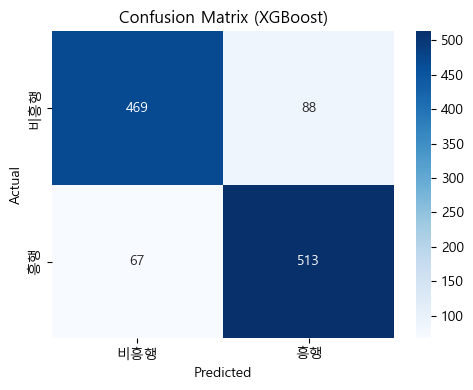

✅ [XGBoost 분류 성능 평가(튜닝 모델)]
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       557
           1       0.76      0.82      0.78       580

    accuracy                           0.77      1137
   macro avg       0.77      0.77      0.77      1137
weighted avg       0.77      0.77      0.77      1137



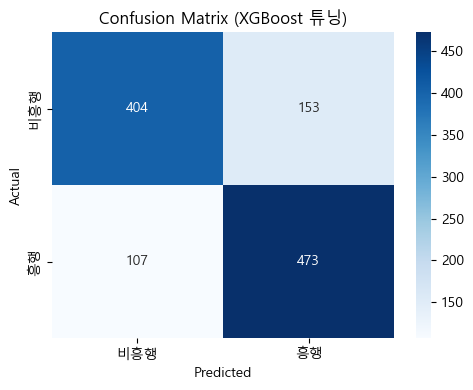

In [20]:
# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# feature 및 target 정의
features = [
    '총_생활인구', '인구당_지출금액', '소득대비_지출',
    '인구당_집객시설수', '순개업률', '유사_업종_경쟁도',
    '점포당_거래건수', '상권_변화_지표', '폐업_비율', '유동_직장_비율'
]

df_model = df_filtered[features + ['흥행_여부']].copy()
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.dropna(inplace=True)

X = df_model[features]
y = df_model['흥행_여부']

# 정규화
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost 기본 모델
xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42
)


# XGBoost 튜닝 모델
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# 학습
xgb_model.fit(X_train, y_train)
xgb_clf.fit(X_train, y_train)

# 기본 XGBoost 모델 예측 및 평가
y_pred_model = xgb_model.predict(X_test)

print("✅ [XGBoost 분류 성능 평가]")
print(classification_report(y_test, y_pred_model))

# 혼동 행렬 시각화 (기본 모델)
cm_model = confusion_matrix(y_test, y_pred_model)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues',
            xticklabels=['비흥행', '흥행'],
            yticklabels=['비흥행', '흥행'])
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 튜닝된 XGBoost 모델 예측 및 평가
y_pred_clf = xgb_clf.predict(X_test)

print("✅ [XGBoost 분류 성능 평가(튜닝 모델)]")
print(classification_report(y_test, y_pred_clf))

# 혼동 행렬 시각화 (튜닝 모델)
cm_clf = confusion_matrix(y_test, y_pred_clf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_clf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['비흥행', '흥행'],
            yticklabels=['비흥행', '흥행'])
plt.title("Confusion Matrix (XGBoost 튜닝)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

업종별 상위 상권 TOP 5 추출

In [21]:
# 1. 예측용 입력 데이터프레임 복사
predict_input = df_filtered.copy()

# 2. feature 정의 (훈련에 사용한 피처와 동일해야 함)
features = [
    '총_생활인구', '인구당_지출금액', '소득대비_지출',
    '인구당_집객시설수', '순개업률', '유사_업종_경쟁도',
    '점포당_거래건수', '상권_변화_지표', '폐업_비율', '유동_직장_비율'
]

# 3. 정규화 (학습 시 사용한 scaler 활용)
X_scaled = pd.DataFrame(
    scaler.transform(predict_input[features]),
    columns=features
)

# 4. 튜닝 모델 기반 안정적인 흥행 확률 예측
predict_input['흥행_확률'] = xgb_clf.predict_proba(X_scaled)[:, 1]

# 5. 필터링: 상위 30개 업종 & 15개 상권만 유지
predict_input = predict_input[
    (predict_input['서비스_업종_코드_명'].isin(top_industries)) &
    (predict_input['상권_코드'].isin(top15_areas))
].copy()

# 6. 조합 중복 제거 및 극단 확률 제거
predict_input = predict_input.drop_duplicates(subset=['서비스_업종_코드_명', '상권_코드'])
#predict_input = predict_input[
    #~((predict_input['흥행_확률'] == 1.0) | (predict_input['흥행_확률'] == 0))
#].copy()

# 7. 상권 코드 → 상권명 매핑
area_name_map = dfs['area'][['상권_코드', '상권_코드_명']].drop_duplicates().set_index('상권_코드')['상권_코드_명'].to_dict()
predict_input['상권_명'] = predict_input['상권_코드'].map(area_name_map)

# 8. 업종별 확률 정렬 및 Top 5 추천
top_recommend = predict_input.sort_values(['서비스_업종_코드_명', '흥행_확률'], ascending=[True, False])
top_5_per_category = top_recommend.groupby('서비스_업종_코드_명').head(5)

# 9. 결과 출력
print("✅ 업종별 상위 5개 상권 추천 (XGBoost 기반):")
display(top_5_per_category[['상권_명', '서비스_업종_코드_명', '흥행_확률']])

✅ 업종별 상위 5개 상권 추천 (XGBoost 기반):


,상권_명,서비스_업종_코드_명,흥행_확률
320,"신촌역(신촌역, 신촌로터리)",문구,0.977525
620,교대역(법원.검찰청),문구,0.847163
1324,종로?청계 관광특구,문구,0.799369
924,선릉역,문구,0.726840
1020,포스코사거리,문구,0.672627
...,...,...,...
720,강남역,화장품,0.897028
1212,명동 남대문 북창동 다동 무교동 관광특구,화장품,0.875347
624,교대역(법원.검찰청),화장품,0.681820
1328,종로?청계 관광특구,화장품,0.669017


흥행 확률 분포 검증

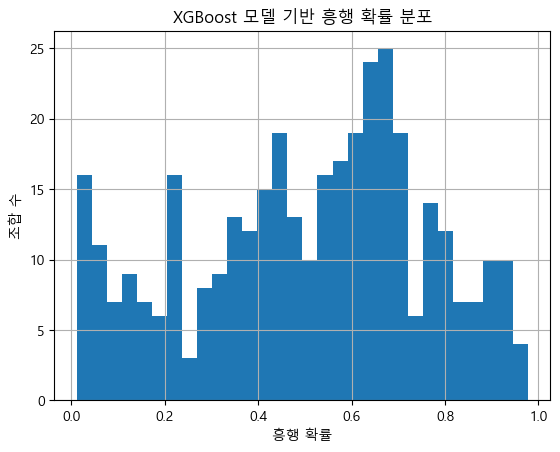

In [22]:
# 전체 흥행 확률 히스토그램
predict_input['흥행_확률'].hist(bins=30)
plt.title("XGBoost 모델 기반 흥행 확률 분포")
plt.xlabel("흥행 확률")
plt.ylabel("조합 수")
plt.show()

변수 간 상관관계 분석

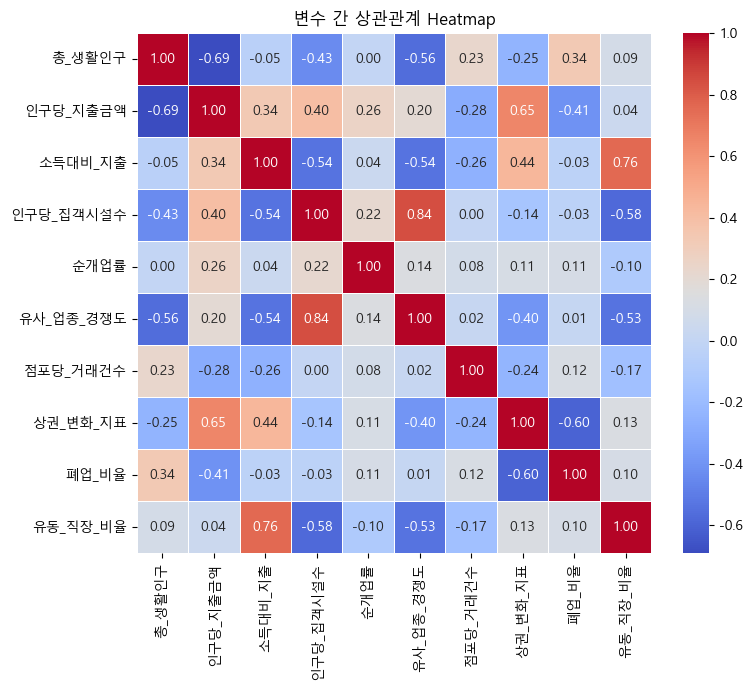

In [23]:
# 운영체제에 맞는 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 분석 대상 변수만 선택
corr_features = [
    '총_생활인구', '인구당_지출금액', '소득대비_지출',
    '인구당_집객시설수', '순개업률', '유사_업종_경쟁도',
    '점포당_거래건수', '상권_변화_지표', '폐업_비율', '유동_직장_비율'
]

# 상관계수 행렬 계산
corr_matrix = df_filtered[corr_features].corr()

# 시각화
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("변수 간 상관관계 Heatmap")
plt.tight_layout()
plt.show()

모델 기본 해석을 위한 SHAP 코드

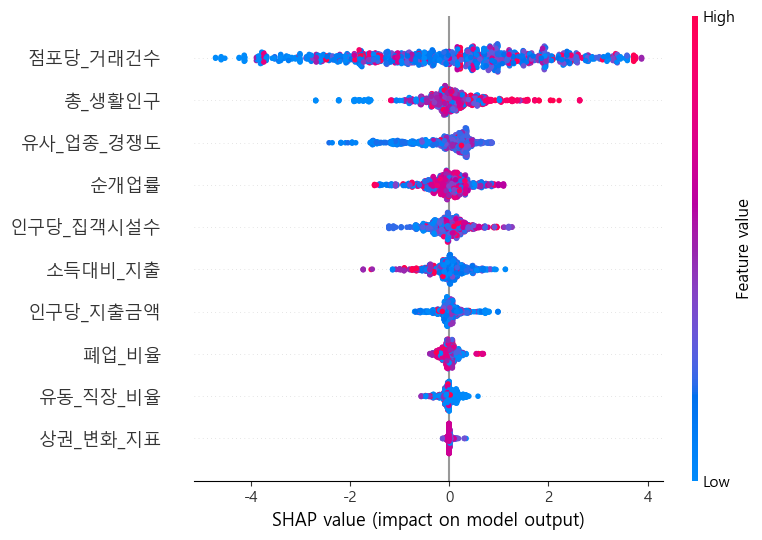

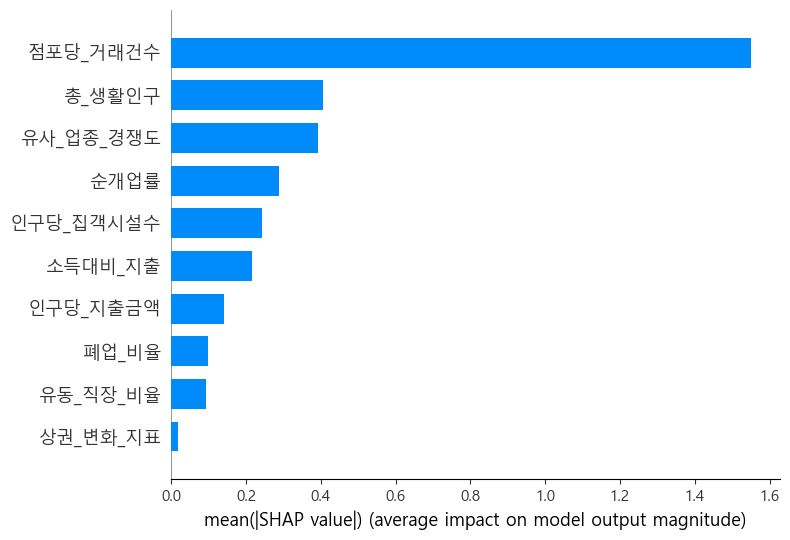

In [24]:
# 트리 기반 모델용 explainer 생성
explainer = shap.Explainer(xgb_model)

#  SHAP 값 계산
shap_values = explainer(X_test)

# 요약 플롯 (전체 변수의 중요도 및 분포 시각화)
shap.summary_plot(shap_values, X_test)

# 바 플롯 (중요도 순으로만 시각화, 변수 영향 순서 파악용)
shap.summary_plot(shap_values, X_test, plot_type="bar")

흥행 확률 기반 Folium 지도 시각화

In [25]:
# 1. 좌표 변환 함수
transformer = Transformer.from_crs("epsg:2097", "epsg:4326", always_xy=True)
def convert_to_latlon(row):
    lon, lat = transformer.transform(row['엑스좌표_값'], row['와이좌표_값'])
    return pd.Series({'경도': lon, '위도': lat})

# 2. 영역 데이터 처리
area_df = pd.read_csv("C:/Users/서울시 상권분석서비스(영역-상권).csv", encoding='euc-kr')
area_df[['경도', '위도']] = area_df.apply(convert_to_latlon, axis=1)

# 3. 병합
predict_geo = predict_input.merge(
    area_df[['상권_코드', '경도', '위도']],
    on='상권_코드',
    how='left'
)

# 4. 업종별 Top3 추출
top3_per_category = (
    predict_geo
    .sort_values(['서비스_업종_코드_명', '흥행_확률'], ascending=[True, False])
    .groupby('서비스_업종_코드_명')
    .head(3)
    .reset_index(drop=True)
)

# 5. 업종별 색상 매핑
unique_categories = top3_per_category['서비스_업종_코드_명'].unique()
cmap = cm.get_cmap('tab20', len(unique_categories))
color_dict = {cat: mcolors.to_hex(cmap(i)) for i, cat in enumerate(unique_categories)}

# 6. 마커 분산을 위한 업종별 인덱스 설정
category_index_map = {cat: i for i, cat in enumerate(unique_categories)}

# 7. 지도 생성
m = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# 8. 마커 추가
for _, row in top3_per_category.iterrows():
    업종 = row['서비스_업종_코드_명']
    i = category_index_map[업종]

    # 좌표 살짝 이동 (중복 방지)
    offset = i * 0.0002
    위도 = row['위도'] + offset
    경도 = row['경도'] + offset

    folium.CircleMarker(
        location=[위도, 경도],
        radius=row['흥행_확률'] * 30,
        color=color_dict[업종],
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['상권_명']}</b><br>"
            f"업종: {업종}<br>"
            f"흥행 확률: {round(row['흥행_확률'], 3)}",
            max_width=300
        )
    ).add_to(m)

# 9. 범례(HTML 삽입)
legend_html = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    top: 50px;
    right: 50px;
    z-index: 1000;
    background-color: white;
    border: 2px solid gray;
    border-radius: 5px;
    padding: 10px;
    font-size: 14px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
">
<b>업종별 색상</b><br>
""" + "".join(
    f'<div><span style="background-color:{color_dict[cat]};width:12px;height:12px;display:inline-block;margin-right:5px;"></span>{cat}</div>'
    for cat in unique_categories
) + """
</div>
{% endmacro %}
"""

legend = MacroElement()
legend._template = Template(legend_html)
m.get_root().add_child(legend)

# 10. 저장
m.save("업종중심_흥행지도_범례_분산.html")
m

C:\Users\shs86\AppData\Local\Temp\ipykernel_8444\1633489082.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_categories))
